# All Resting State EEG

## Eyes Closed

In [2]:
import os
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from scipy.signal import welch

### No Aces

In [3]:
no_aces_EC = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed"
print(os.path.exists(no_aces_EC))

True


In [4]:
files = glob.glob(os.path.join(no_aces_EC, "*AveOverTrials.txt"))

fs = 500  

In [5]:
all_subject_psd_ec = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_ec.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_ec))

Subjects: 47


In [6]:
all_subject_psd_ec = np.vstack(all_subject_psd_ec)

group_psd_ec = np.mean(all_subject_psd_ec, axis=0)

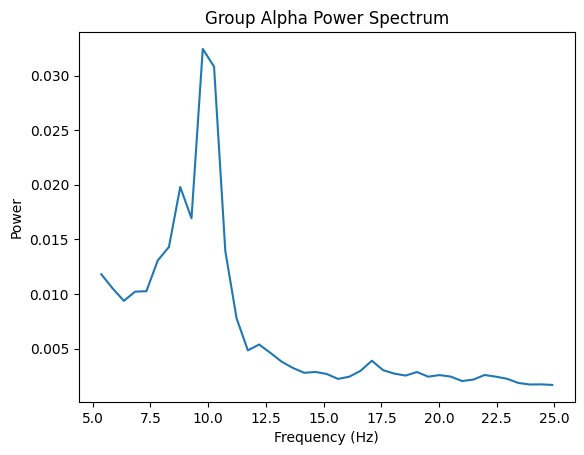

In [7]:
alpha_mask = (freqs >= 5) & (freqs <= 25)

plt.plot(freqs[alpha_mask], group_psd_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

#### 2nd version no Aces EC

In [8]:
eps = 1e-12
log_psd = np.log10(group_psd_ec + eps)

In [9]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm_ec = log_psd - baseline

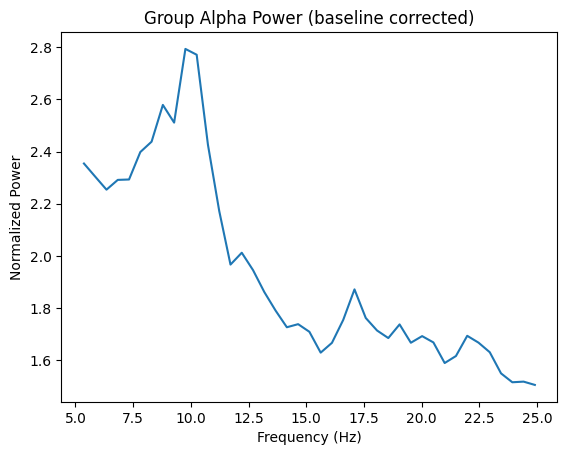

In [10]:
plt.plot(freqs[alpha_mask], log_psd_norm_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

#### Z-Score No_ACEs EC

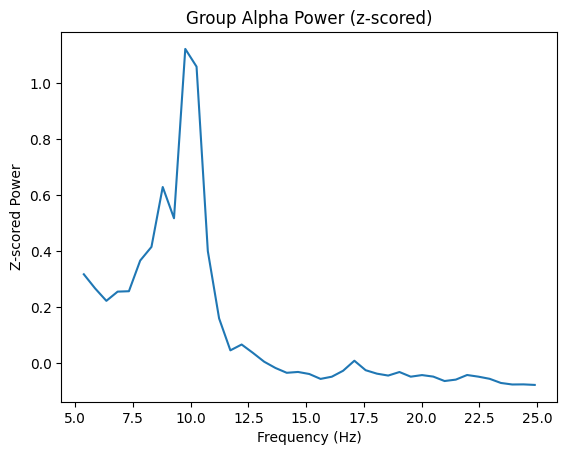

In [11]:
psd_mean_ec = np.mean(group_psd_ec)
psd_std_ec = np.std(group_psd_ec)
psd_z_ec = (group_psd_ec - psd_mean_ec) / psd_std_ec

plt.plot(freqs[alpha_mask], psd_z_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

#### Centered UV version No_ACEs EC

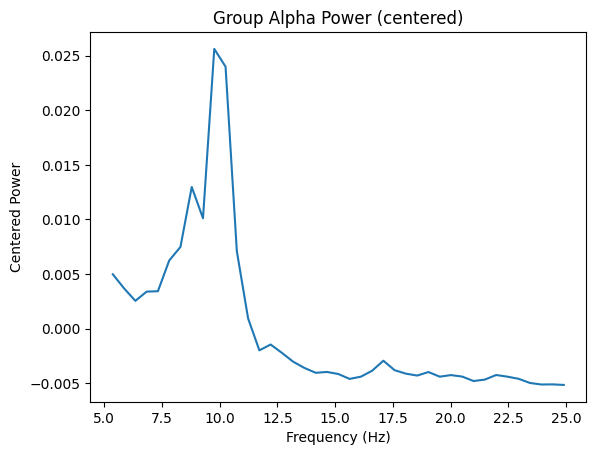

In [12]:

alpha_power_ec = group_psd_ec[alpha_mask]
alpha_power_centered_ec = alpha_power_ec - np.mean(alpha_power_ec)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

#### Z-Score version

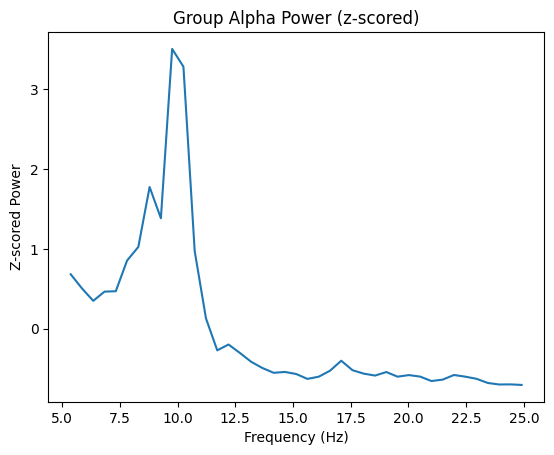

In [13]:
alpha_power_ec = group_psd_ec[alpha_mask]
alpha_power_z_ec = (alpha_power_ec - np.mean(alpha_power_ec)) / np.std(alpha_power_ec)

plt.plot(freqs[alpha_mask], alpha_power_z_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

## ACEs EC

In [14]:
aces_ec = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed\\EC_ACES"
print(os.path.exists(aces_ec))

True


In [15]:
files = glob.glob(os.path.join(aces_ec, "*AveOverTrials.txt"))

fs = 500 

In [16]:
all_subject_psd_ace_ec = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_ace_ec.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_ace_ec))

Subjects: 151


In [17]:
all_subject_psd_ace_ec = np.vstack(all_subject_psd_ace_ec)

group_psd_ace_ec = np.mean(all_subject_psd_ace_ec, axis=0)

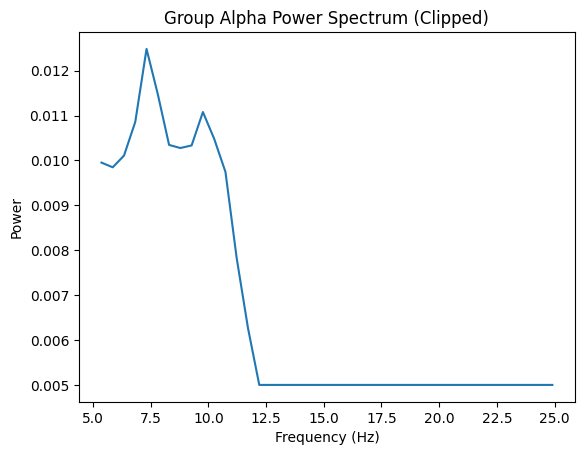

In [18]:
# Clip power values to desired range
clipped_psd_aces_ec = np.clip(group_psd_ace_ec[alpha_mask], 0.005, 0.030)

# Plot
plt.plot(freqs[alpha_mask], clipped_psd_aces_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum (Clipped)")
plt.show()

#### 2nd visual ACEs EC

In [19]:
eps = 1e-12
log_psd = np.log10(group_psd_ace_ec + eps)

In [20]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm_ace_ec = log_psd - baseline

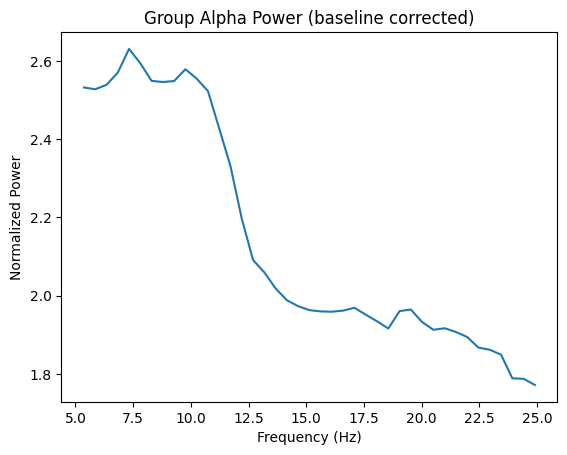

In [21]:
plt.plot(freqs[alpha_mask], log_psd_norm_ace_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

#### Z-score of 2nd verison

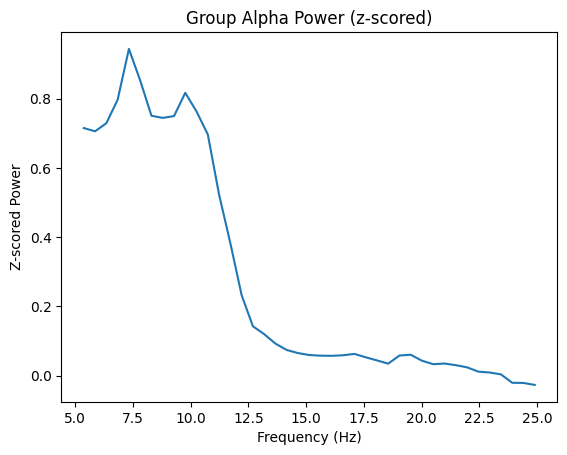

In [22]:
psd_mean = np.mean(group_psd_ace_ec)
psd_std = np.std(group_psd_ace_ec)
psd_z_ace_ec = (group_psd_ace_ec - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z_ace_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

#### UV version [center]

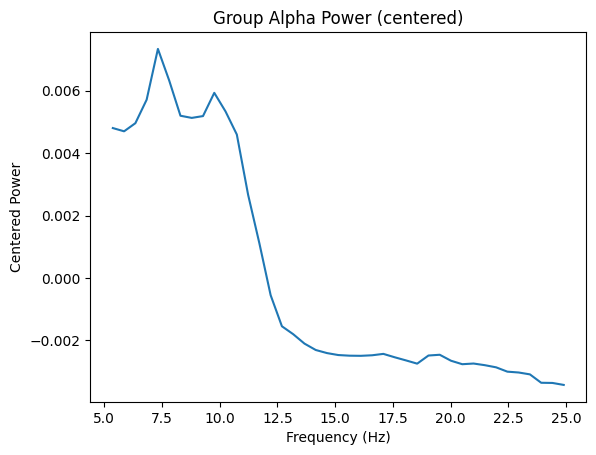

In [23]:
alpha_power_aces_ec = group_psd_ace_ec[alpha_mask]
alpha_power_centered_aces_ec = alpha_power_aces_ec - np.mean(alpha_power_aces_ec)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_aces_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

#### Z-score of UV

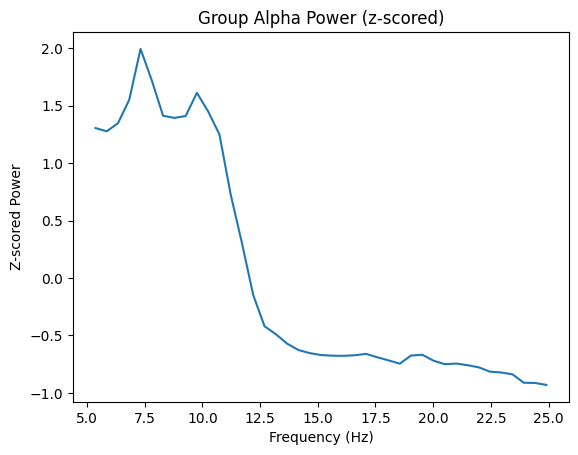

In [24]:
alpha_power_aces_ec = group_psd_ace_ec[alpha_mask]
alpha_power_z_ace_ec = (alpha_power_aces_ec - np.mean(alpha_power_aces_ec)) / np.std(alpha_power_aces_ec)

plt.plot(freqs[alpha_mask], alpha_power_z_ace_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# Eyes Open

## No ACEs

In [25]:
no_aces ="C:\\Users\\emros\\OneDrive\\Desktop\\EO_No_ACES_ processed"
print(os.path.exists(no_aces))

True


In [26]:
files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))

fs = 500 

In [27]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 48


In [28]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd = np.mean(all_subject_psd, axis=0)

#### Visual 1

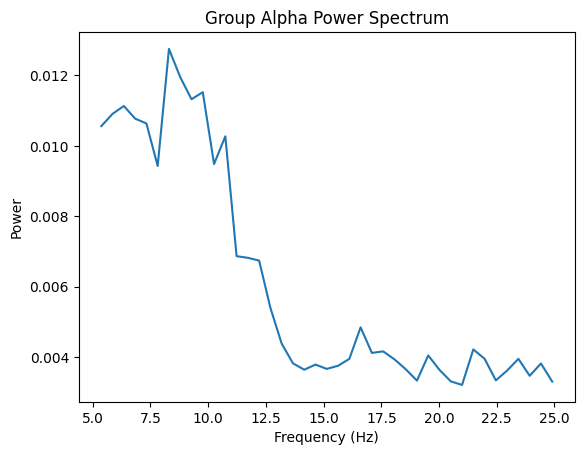

In [29]:
plt.plot(freqs[alpha_mask], group_psd[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

#### 2nd better version

In [30]:
eps = 1e-12
log_psd = np.log10(group_psd + eps)

In [31]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

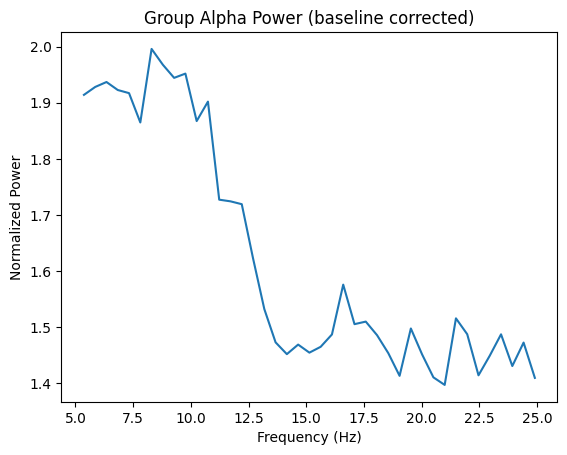

In [32]:
plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

#### Z score

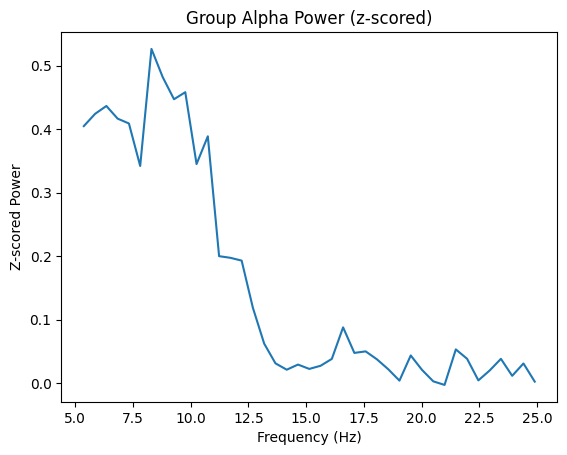

In [33]:
psd_mean = np.mean(group_psd)
psd_std = np.std(group_psd)
psd_z = (group_psd - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

#### Anotha one (UV version)

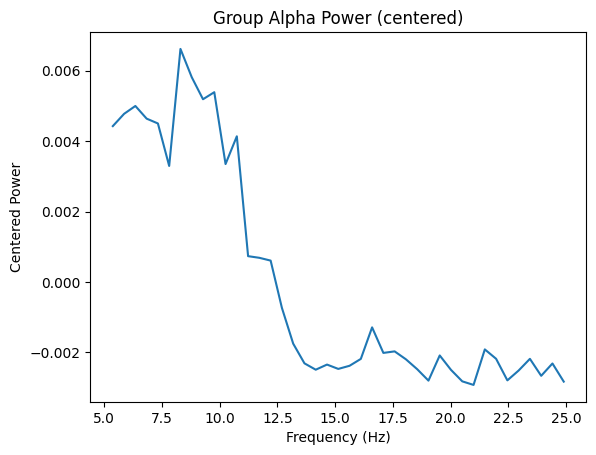

In [34]:
alpha_power = group_psd[alpha_mask]
alpha_power_centered = alpha_power - np.mean(alpha_power)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

#### Z score or UV

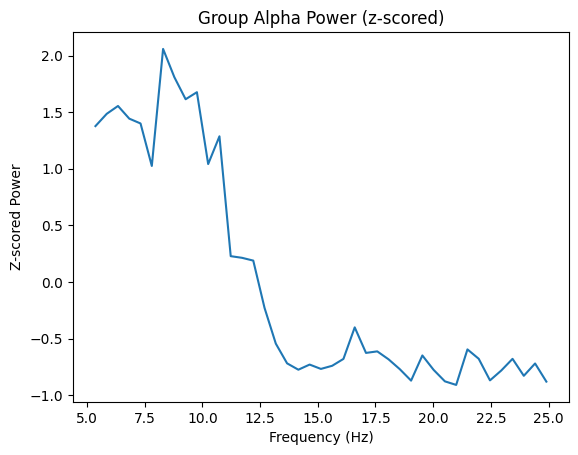

In [35]:
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

plt.plot(freqs[alpha_mask], alpha_power_z)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

## ACEs {EO}

In [36]:
ACEs = "C:\\Users\\emros\\OneDrive\\Desktop\\EO_ACES_Processed"

In [37]:
files = glob.glob(os.path.join(ACEs, "*AveOverTrials.txt"))

fs = 500

In [38]:
all_subject_psd_aces = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_aces.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_aces))

Subjects: 88


In [39]:
all_subject_psd_ACE = np.vstack(all_subject_psd_aces)

group_psd_ACE = np.mean(all_subject_psd_ACE, axis=0)

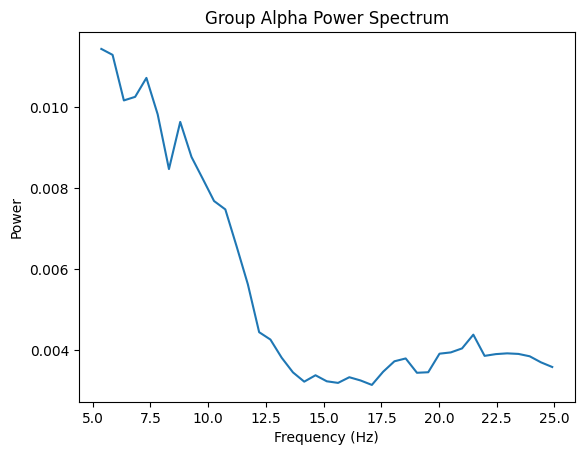

In [40]:
plt.plot(freqs[alpha_mask], group_psd_ACE[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

In [41]:
eps = 1e-12
log_psd_ace = np.log10(group_psd_ACE + eps)

In [42]:
# baseline = mean across all frequencies
baseline_ace = np.mean(log_psd_ace)
log_psd_norm_ACE = log_psd_ace - baseline_ace

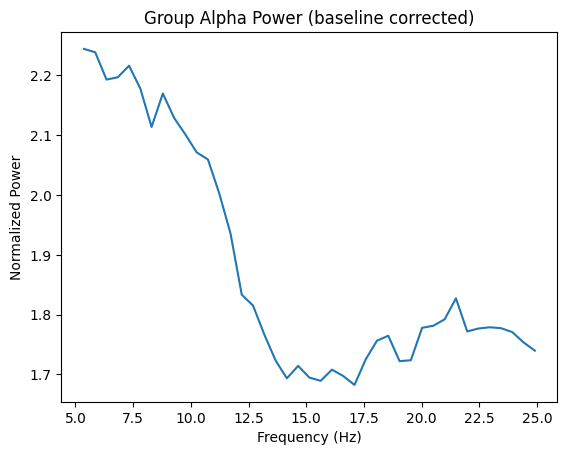

In [43]:
plt.plot(freqs[alpha_mask], log_psd_norm_ACE[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

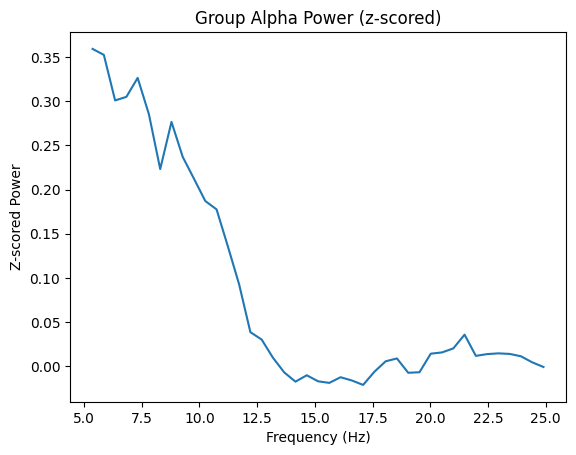

In [44]:
psd_mean_ace = np.mean(group_psd_ACE)
psd_std_ace = np.std(group_psd_ACE)
psd_z_ace = (group_psd_ACE - psd_mean_ace) / psd_std_ace

plt.plot(freqs[alpha_mask], psd_z_ace[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

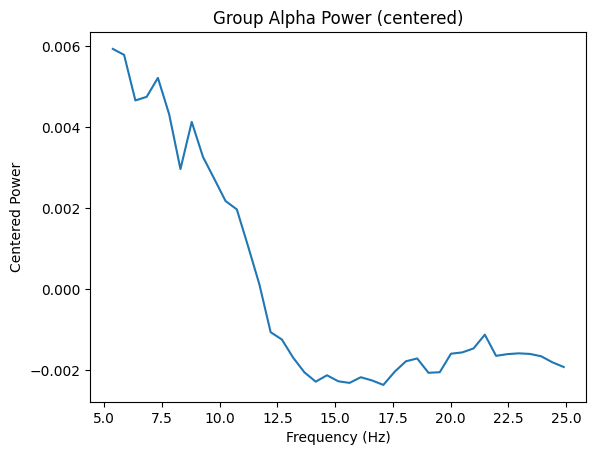

In [45]:
alpha_power_ace = group_psd_ACE[alpha_mask]
alpha_power_centered_ace = alpha_power_ace - np.mean(alpha_power_ace)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

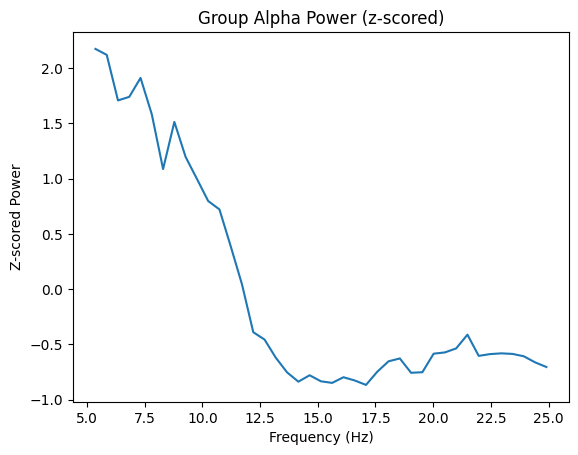

In [46]:
alpha_power_ace = group_psd_ACE[alpha_mask]
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

plt.plot(freqs[alpha_mask], alpha_power_z_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# Final Visuals

### Eyes open

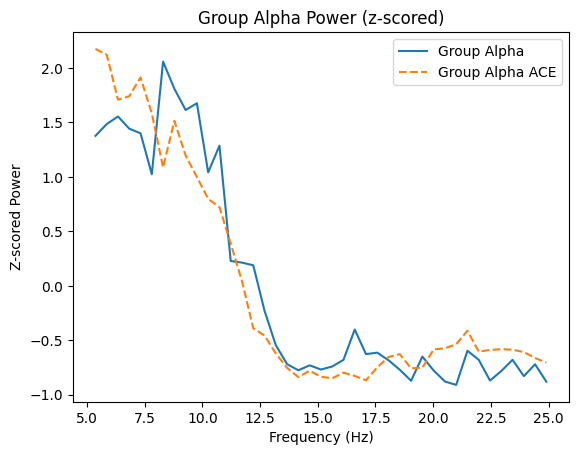

In [47]:
# First line
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_ACE[alpha_mask]  # use the actual ACE data here
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

### Eyes Closed

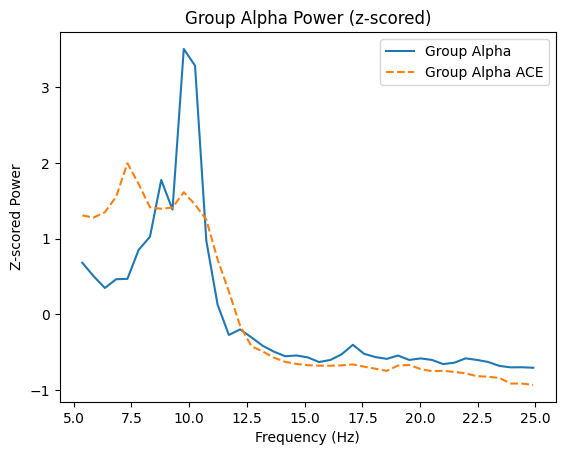

In [48]:
# First line
alpha_power_ec = group_psd_ec[alpha_mask]
alpha_power_z_ec = (alpha_power_ec - np.mean(alpha_power_ec)) / np.std(alpha_power_ec)

# Second line (ACE)
alpha_power_ace_ec = group_psd_ace_ec[alpha_mask]  # use the actual ACE data here
alpha_power_z_ace_ec = (alpha_power_ace_ec - np.mean(alpha_power_ace_ec)) / np.std(alpha_power_ace_ec)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z_ec, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace_ec, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

# All

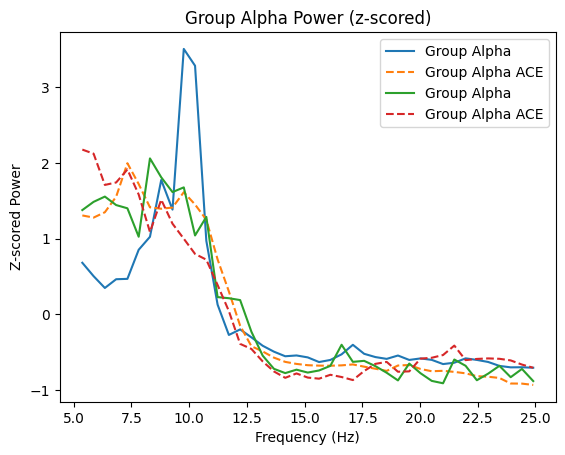

In [49]:
# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z_ec, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace_ec, label="Group Alpha ACE", linestyle='--')

plt.plot(freqs[alpha_mask], alpha_power_z, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()